In [4]:
# Read thyroid.names to understand the data format
with open('/content/thyroid.names', 'r') as f:
    thyroid_names_content = f.read()
print(thyroid_names_content)

;
; Thyroid disease records supplied by the Garavan Institute and J. Ross
; Quinlan, New South Wales Institute, Syndney, Australia.
;
; 1987.
;

sick, negative.			|  classes

age:				continuous.
sex:				M, F.
on thyroxine:			f, t.
query on thyroxine:		f, t.
on antithyroid medication:	f, t.
sick:				f, t.
pregnant:			f, t.
thyroid surgery:		f, t.
I131 treatment:			f, t.
query hypothyroid:		f, t.
query hyperthyroid:		f, t.
lithium:			f, t.
goitre:				f, t.
tumor:				f, t.
hypopituitary:			f, t.
psych:				f, t.
TSH measured:			f, t.
TSH:				continuous.
T3 measured:			f, t.
T3:				continuous.
TT4 measured:			f, t.
TT4:				continuous.
T4U measured:			f, t.
T4U:				continuous.
FTI measured:			f, t.
FTI:				continuous.
TBG measured:			f, t.
TBG:				continuous.
referral source:		WEST, STMW, SVHC, SVI, SVHD, other.



In [5]:
# Load thyroid.data into a pandas DataFrame
# Based on typical .names files, the .data file is often comma-separated or space-separated.
# Let's try comma-separated first.
df_thyroid_data = pd.read_csv('/content/thyroid.data', header=None)
display(df_thyroid_data.head())

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,negative.|3733
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,negative.|1442
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,negative.|2965
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,negative.|806
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,negative.|2807


/tmp/ipykernel_23615/3865386003.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("?", np.nan)


--- BASELINE MODEL ---
Accuracy:  0.9620890774125133
Precision:  0.7784810126582279
Recall:  0.5324675324675324
F1 Score:  0.6323907455012854
Confusion Matrix:
 [[3506   35]
 [ 108  123]]


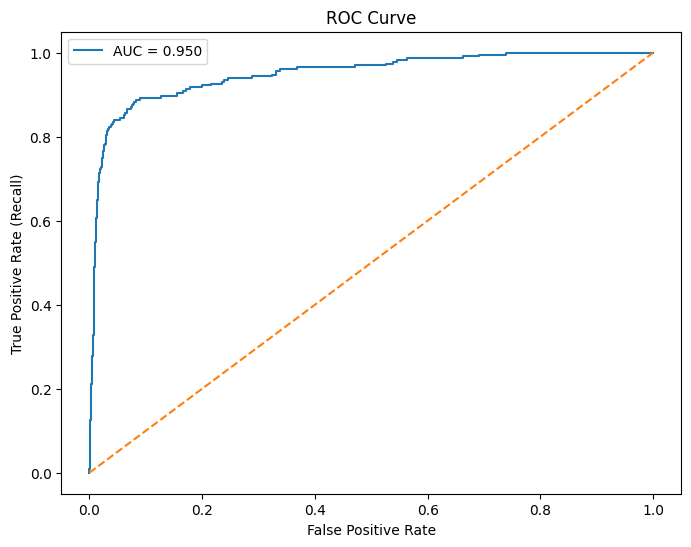


--- THRESHOLD TUNING ---

At tau baseline (0.500):
Precision:  0.7784810126582279
Recall:  0.5324675324675324
Confusion Matrix:
 [[3506   35]
 [ 108  123]]

At tau cost (0.187):
Precision:  0.5693215339233039
Recall:  0.8354978354978355
Confusion Matrix:
 [[3395  146]
 [  38  193]]

At tau recall (0.043):
Precision:  0.27463863337713534
Recall:  0.9047619047619048
Confusion Matrix:
 [[2989  552]
 [  22  209]]

At tau youden (0.103):
Precision:  0.41164658634538154
Recall:  0.8874458874458875
Confusion Matrix:
 [[3248  293]
 [  26  205]]

--- ALGORITHMIC WEIGHTING ---
Inverse Frequency Recall:  0.8961038961038961
Cost-Sensitive Recall:  0.8787878787878788

--- CUSTOM FROM-SCRATCH RESAMPLING ---

Model with Undersampling metrics:
Precision:  0.3234375
Recall:  0.8961038961038961
Confusion Matrix:
 [[3108  433]
 [  24  207]]

Model with Oversampling metrics:
Precision:  0.35800344234079173
Recall:  0.9004329004329005
Confusion Matrix:
 [[3168  373]
 [  23  208]]

Model with SMOTE metrics

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. DATA PREPROCESSING & IMPUTATION
# ==========================================

# Load data
df = pd.read_csv("/content/thyroid.data", header=None) # Corrected: Remove sep="|"

# Define columns
cols = [
    "age", "sex", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication",
    "sick", "pregnant", "thyroid_surgery", "I131_treatment", "query_hypothyroid",
    "query_hyperthyroid", "lithium", "goitre", "tumor", "hypopituitary", "psych",
    "TSH_measured", "TSH", "T3_measured", "T3",
    "TT4_measured", "TT4", "T4U_measured", "T4U",
    "FTI_measured", "FTI", "TBG_measured", "TBG",
    "referral_source", "class_raw" # Temporarily rename the last column
]
df.columns = cols

# Replace '?' with NaN
df = df.replace("?", np.nan)

# Impute missing medical readings with 0 if not measured
for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    measured_col = col + "_measured"
    # Ensure the column type is object before applying string operations
    df[col] = df[col].astype(str)
    df[col] = df.apply(lambda row: 0 if row[measured_col] == "f" else row[col], axis=1)
    df[col] = pd.to_numeric(df[col], errors='coerce') # Convert back to numeric

# Median/Mode imputation for demographics
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

# One-hot encoding for categorical variables
binary_cols = [
    "sex", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication",
    "sick", "pregnant", "thyroid_surgery", "I131_treatment", "query_hypothyroid",
    "query_hyperthyroid", "lithium", "goitre", "tumor", "hypopituitary", "psych",
    "TSH_measured", "T3_measured", "TT4_measured",
    "T4U_measured", "FTI_measured", "TBG_measured"
]
df = pd.get_dummies(df, columns=binary_cols, drop_first=True, dtype=int)

# Target variable formatting: Extract actual 'class' from 'class_raw'
df['class'] = df['class_raw'].apply(lambda x: x.split('|')[0].strip())
df["class"] = (df["class"] == "sick.").astype(int)

# Drop referral_source and the raw class column
df = df.drop(columns=["referral_source", "class_raw"])

# Separate features and target
X = df.drop(columns=["class"])
y = df["class"]


# ==========================================
# 2. BASELINE MODEL EVALUATION
# ==========================================

print("--- BASELINE MODEL ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # [cite: 135]
model = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000))])

y_pred = cross_val_predict(model, X, y, cv=skf) # [cite: 137]

print("Accuracy: ", accuracy_score(y, y_pred)) # [cite: 138]
print("Precision: ", precision_score(y, y_pred))
print("Recall: ", recall_score(y, y_pred))
print("F1 Score: ", f1_score(y, y_pred)) # [cite: 139]
print("Confusion Matrix:\n", confusion_matrix(y, y_pred)) # [cite: 141]


# ==========================================
# 3. ROC CURVE & AUC PLOT
# ==========================================

y_scores = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1] # [cite: 161]
fpr, tpr, thresholds = roc_curve(y, y_scores) # [cite: 162]
auc = roc_auc_score(y, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}") # [cite: 164]
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate") # [cite: 165]
plt.ylabel("True Positive Rate (Recall)") # [cite: 166]
plt.title("ROC Curve")
plt.legend()
plt.show() # [cite: 167]


# ==========================================
# 4. THRESHOLD TUNING
# ==========================================

print("\n--- THRESHOLD TUNING ---")
thresholds_arr = np.linspace(0, 1, 1001) # [cite: 194]

# Cost Optimization [cite: 194, 195, 196, 197, 198, 199, 200, 201]
C_FN, C_FP = 10, 1
costs = []
for t in thresholds_arr:
    y_pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t).ravel()
    costs.append(C_FN * fn + C_FP * fp)
tau_cost = thresholds_arr[np.argmin(costs)] # [cite: 202]

# Target Recall [cite: 204, 205, 206, 207, 208]
target_recall = 0.90
tau_recall_list = []
for t in thresholds_arr:
    y_pred_t = (y_scores >= t).astype(int)
    if recall_score(y, y_pred_t) >= target_recall:
        tau_recall_list.append(t)
tau_recall = tau_recall_list[-1] if tau_recall_list else 0 # [cite: 209]

# Youden's J Statistic [cite: 210, 211, 212, 213, 214, 215, 216]
youden_scores = []
for t in thresholds_arr:
    y_pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_scores.append(sensitivity + specificity - 1)
tau_youden = thresholds_arr[np.argmax(youden_scores)] # [cite: 217]

for name, tau in [("baseline", 0.5), ("cost", tau_cost), ("recall", tau_recall), ("youden", tau_youden)]:
    y_pred_tau = (y_scores >= tau).astype(int) # [cite: 230]
    print(f"\nAt tau {name} ({tau:.3f}):") # [cite: 232]
    print("Precision: ", precision_score(y, y_pred_tau)) # [cite: 233]
    print("Recall: ", recall_score(y, y_pred_tau)) # [cite: 234]
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred_tau)) # [cite: 236, 237]


# ==========================================
# 5. ALGORITHMIC CLASS WEIGHTING
# ==========================================

print("\n--- ALGORITHMIC WEIGHTING ---")
# Inverse Frequency [cite: 275, 276, 277, 278]
model_inv = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced"))])
y_pred_inv = cross_val_predict(model_inv, X, y, cv=skf) # [cite: 279]

# Cost-Sensitive [cite: 280, 281, 282, 283, 284, 285, 286]
model_cost = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, class_weight={0: 1, 1: 10}))])
y_pred_cost_model = cross_val_predict(model_cost, X, y, cv=skf) # [cite: 288]

print("Inverse Frequency Recall: ", recall_score(y, y_pred_inv)) # [cite: 305]
print("Cost-Sensitive Recall: ", recall_score(y, y_pred_cost_model)) # [cite: 318]


# ==========================================
# 6. FROM-SCRATCH RESAMPLING & CUSTOM CV
# ==========================================

print("\n--- CUSTOM FROM-SCRATCH RESAMPLING ---")

def random_undersample(X_train, y_train, random_state=42):
    np.random.seed(random_state)
    majority_indices = np.where(y_train == 0)[0]
    minority_indices = np.where(y_train == 1)[0]
    sampled_majority = np.random.choice(majority_indices, size=len(minority_indices), replace=False)
    combined = np.concatenate([minority_indices, sampled_majority])
    np.random.shuffle(combined)
    return X_train.iloc[combined].reset_index(drop=True), y_train.iloc[combined].reset_index(drop=True)

def random_oversample(X_train, y_train, random_state=42):
    np.random.seed(random_state)
    majority_indices = np.where(y_train == 0)[0]
    minority_indices = np.where(y_train == 1)[0]
    deficit = len(majority_indices) - len(minority_indices)
    duplicated_minority = np.random.choice(minority_indices, size=deficit, replace=True)
    combined = np.concatenate([majority_indices, minority_indices, duplicated_minority])
    np.random.shuffle(combined)
    return X_train.iloc[combined].reset_index(drop=True), y_train.iloc[combined].reset_index(drop=True)

def smote_from_scratch(X_train, y_train, k=5, random_state=42):
    np.random.seed(random_state)
    minority_X = X_train[y_train == 1].values
    n_synthetic = sum(y_train == 0) - sum(y_train == 1)

    nn = NearestNeighbors(n_neighbors=k+1).fit(minority_X)
    synthetic_samples = []

    for _ in range(n_synthetic):
        base_idx = np.random.randint(0, len(minority_X))
        base_point = minority_X[base_idx]
        _, neighbor_indices = nn.kneighbors([base_point])
        chosen_neighbor_idx = np.random.choice(neighbor_indices[0][1:])
        neighbor_point = minority_X[chosen_neighbor_idx]
        lambda_val = np.random.random()
        synthetic_samples.append(base_point + lambda_val * (neighbor_point - base_point))

    synthetic_df = pd.DataFrame(synthetic_samples, columns=X_train.columns)
    synthetic_y = pd.Series(np.ones(n_synthetic), name=y_train.name)

    X_res = pd.concat([X_train, synthetic_df], axis=0).reset_index(drop=True)
    y_res = pd.concat([y_train, synthetic_y], axis=0).reset_index(drop=True)
    return X_res, y_res

# Helper function to evaluate custom resampling properly (Only resample the training fold to avoid data leakage)
def evaluate_custom_resampling(X, y, resampling_func):
    y_pred_eval = np.zeros_like(y, dtype=int)
    for train_idx, test_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test = X.iloc[test_idx]

        # Apply resampling ONLY on the training data
        X_train_res, y_train_res = resampling_func(X_train, y_train)

        # Scale and Train
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=10000)
        clf.fit(X_train_scaled, y_train_res)

        # Predict on unaltered test fold
        y_pred_eval[test_idx] = clf.predict(X_test_scaled)

    return y_pred_eval

# Run evaluations
preds_under = evaluate_custom_resampling(X, y, random_undersample)
preds_over = evaluate_custom_resampling(X, y, random_oversample)
preds_smote = evaluate_custom_resampling(X, y, smote_from_scratch)

for name, preds in [("Undersampling", preds_under), ("Oversampling", preds_over), ("SMOTE", preds_smote)]:
    print(f"\nModel with {name} metrics:")
    print("Precision: ", precision_score(y, preds))
    print("Recall: ", recall_score(y, preds))
    print("Confusion Matrix:\n", confusion_matrix(y, preds))